In [ ]:
import pandas as pd
import numpy as np
import math as mat
from sklearn import preprocessing
from matplotlib import pyplot as plt

header = [ 'srcip','sport', 'dstip', 'dsport', 'proto',
          'state', 'dur', 'sbytes', 'dbytes', 'sttl',
          'dttl', 'sloss', 'dloss', 'service', 'Sload',
          'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin',
          'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth',
          'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime',
          'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
          'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd',
          'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
          'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'
         ]
dt= pd.read_csv(r'/content/UNSW-NB15_1.csv', names = header)
dt

<ipython-input-29-e98709e75011>:18: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  dt= pd.read_csv(r'/content/UNSW-NB15_1.csv', names = header)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699996,59.166.0.8,12520,149.171.126.6,31010,tcp,FIN,0.020383,320,1874,31,...,0,8,20,7,5,1,1,4,NaN,0
699997,59.166.0.0,18895,149.171.126.9,80,tcp,FIN,1.402957,19410,1087890,31,...,0,1,1,2,7,2,2,2,NaN,0
699998,59.166.0.0,30103,149.171.126.5,5190,tcp,FIN,0.007108,2158,2464,31,...,0,13,13,6,7,2,1,2,NaN,0
699999,59.166.0.6,30388,149.171.126.5,111,udp,CON,0.004435,568,304,31,...,0,10,13,6,5,1,1,3,NaN,0


In [ ]:
print(dt.nunique())

srcip                   40
sport               100270
dstip                   44
dsport               87819
proto                  135
state                   16
dur                 243828
sbytes                7948
dbytes               11898
sttl                    13
dttl                    11
sloss                  275
dloss                  572
service                 13
Sload               391840
Dload               403499
Spkts                  715
Dpkts                 1086
swin                    12
dwin                     4
stcpb               441843
dtcpb               441640
smeansz               1288
dmeansz               1356
trans_depth              6
res_bdy_len            543
Sjit                426221
Djit                454152
Stime                27568
Ltime                27566
Sintpkt             350430
Dintpkt             351748
tcprtt               17050
synack               15769
ackdat               13690
is_sm_ips_ports          2
ct_state_ttl             7
c

In [ ]:
dt.replace(to_replace = '-', value = np.nan, inplace = True)
dt = dt.drop(columns=['attack_cat'])

dt.isna().sum()

srcip                    0
sport                    2
dstip                    0
dsport                   7
proto                    0
state                    0
dur                      0
sbytes                   0
dbytes                   0
sttl                     0
dttl                     0
sloss                    0
dloss                    0
service             430656
Sload                    0
Dload                    0
Spkts                    0
Dpkts                    0
swin                     0
dwin                     0
stcpb                    0
dtcpb                    0
smeansz                  0
dmeansz                  0
trans_depth              0
res_bdy_len              0
Sjit                     0
Djit                     0
Stime                    0
Ltime                    0
Sintpkt                  0
Dintpkt                  0
tcprtt                   0
synack                   0
ackdat                   0
is_sm_ips_ports          0
ct_state_ttl             0
c

In [ ]:
dt.dropna(axis = 0, inplace = True)
dt.drop_duplicates(inplace = True)
dt

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,0,3,7,1,3,1,1,1,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,0,12,8,1,2,2,1,1,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,0,6,9,1,1,1,1,1,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,0,7,9,1,1,1,1,1,0
6,59.166.0.6,2142,149.171.126.4,53,udp,CON,0.001134,132,164,31,...,0,0,12,7,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699865,59.166.0.5,51051,149.171.126.9,21,tcp,FIN,1.419832,2934,3742,31,...,1,1,1,1,2,6,1,1,2,0
699905,59.166.0.0,34380,149.171.126.4,21,tcp,FIN,1.423697,2934,3742,31,...,1,1,1,1,8,4,1,1,3,0
699916,59.166.0.4,53532,149.171.126.6,53,udp,CON,0.001028,146,178,31,...,0,0,1,1,6,4,3,2,2,0
699992,59.166.0.3,48114,149.171.126.3,53,udp,CON,0.001026,146,178,31,...,0,0,1,1,6,5,3,2,2,0


In [ ]:
dt.dtypes

srcip                object
sport                object
dstip                object
dsport               object
proto                object
state                object
dur                 float64
sbytes                int64
dbytes                int64
sttl                  int64
dttl                  int64
sloss                 int64
dloss                 int64
service              object
Sload               float64
Dload               float64
Spkts                 int64
Dpkts                 int64
swin                  int64
dwin                  int64
stcpb                 int64
dtcpb                 int64
smeansz               int64
dmeansz               int64
trans_depth           int64
res_bdy_len           int64
Sjit                float64
Djit                float64
Stime                 int64
Ltime                 int64
Sintpkt             float64
Dintpkt             float64
tcprtt              float64
synack              float64
ackdat              float64
is_sm_ips_ports     

In [ ]:
dt.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,0,3,7,1,3,1,1,1,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,0,12,8,1,2,2,1,1,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,0,6,9,1,1,1,1,1,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,0,7,9,1,1,1,1,1,0
6,59.166.0.6,2142,149.171.126.4,53,udp,CON,0.001134,132,164,31,...,0,0,12,7,1,2,2,1,1,0


In [ ]:
numerical_columns = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload',
                     'Spkts', 'Dpkts', 'stcpb', 'dtcpb',
                     'smeansz', 'dmeansz', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt',
                     'Dintpkt', 'tcprtt', 'synack', 'ackdat'
                    ]
categorical_columns = ['srcip', 'dstip', 'sport', 'dsport', 'proto', 'state',
                       'sttl', 'dttl', 'sloss', 'dloss',
                       'service', 'swin', 'dwin', 'trans_depth', 'res_bdy_len',
                       'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login',
                       'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm',
                       'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'Label'
                      ]

# Identify non-numeric values in 'sport' and 'dsport'
non_numeric_values_sport = pd.to_numeric(dt['sport'], errors='coerce').isna()
non_numeric_values_dsport = pd.to_numeric(dt['dsport'], errors='coerce').isna()

# Print or handle non-numeric values
print("Non-numeric values in 'sport':")
print(dt.loc[non_numeric_values_sport, 'sport'])

print("Non-numeric values in 'dsport':")
print(dt.loc[non_numeric_values_dsport, 'dsport'])

# Handle or remove non-numeric values
dt['sport'] = pd.to_numeric(dt['sport'], errors='coerce')
dt['dsport'] = pd.to_numeric(dt['dsport'], errors='coerce')

# Drop rows with NaN values after conversion
dt = dt.dropna()


Non-numeric values in 'sport':
Series([], Name: sport, dtype: object)
Non-numeric values in 'dsport':
Series([], Name: dsport, dtype: object)


In [ ]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
for col in categorical_columns:
    dt[col] = label_encoder.fit_transform(dt[col].astype(str))

scaler = preprocessing.StandardScaler()

# Handle non-numeric values in numerical columns before scaling
for col in numerical_columns:
    try:
        dt[col] = pd.to_numeric(dt[col], errors='coerce')
        # Skip scaling if the column is categorical (already encoded)
        if col not in categorical_columns:
            dt[[col]] = scaler.fit_transform(dt[[col]].values.reshape(-1, 1))
    except ValueError as e:
        print(f"Error processing column {col}: {e}")

# Drop rows with NaN values after conversion
dt = dt.dropna()

# Print the DataFrame
print(dt)


        srcip  sport  dstip  dsport  proto  state       dur    sbytes  \
0          10   4181     16     304      1      2 -0.274044 -0.130937   
2          16   4979     17     304      1      2 -0.274016 -0.130616   
3          15  27869     15     304      1      2 -0.273975 -0.130937   
4          13  42596      0     304      1      2 -0.273993 -0.130616   
6          16  12263     14     304      1      2 -0.274009 -0.130937   
...       ...    ...    ...     ...    ...    ...       ...       ...   
699865     15  44073     19      70      0      3  0.361331 -0.066676   
699905     10  26201     14      70      0      3  0.363061 -0.066676   
699916     14  46738     16     304      1      2 -0.274056 -0.130616   
699992     13  40936     13     304      1      2 -0.274057 -0.130616   
699997     10   9563     19     464      0      3  0.353773  0.311181   

          dbytes  sttl  ...  is_ftp_login  ct_ftp_cmd  ct_srv_src  ct_srv_dst  \
0      -0.179180     3  ...             0 

In [ ]:
dt[numerical_columns].describe()

,dur,sbytes,dbytes,Sload,Dload,Spkts,Dpkts,stcpb,dtcpb,smeansz,dmeansz,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat
count,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05,2.522130e+05
mean,7.922059e-17,3.662403e-18,2.287593e-17,1.532575e-17,-8.096727e-17,8.113630e-18,-1.419885e-17,9.387020e-17,-1.391713e-17,5.871113e-17,-1.803029e-18,-6.941662e-17,2.591854e-17,-5.841886e-13,8.282113e-12,-3.245452e-17,-7.775563e-18,-3.200376e-17,2.163635e-17,-4.868178e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-2.745166e-01,-1.326797e-01,-1.801406e-01,-1.279056e-01,-4.456391e-01,-3.653950e-01,-2.960129e-01,-8.665943e-01,-8.655088e-01,-5.861917e-01,-8.286016e-01,-2.910306e-01,-3.356023e-01,-1.745833e+00,-1.745913e+00,-1.859443e-01,-1.678935e-01,-1.284452e-01,-1.350686e-01,-1.131089e-01
25%,-2.740388e-01,-1.306156e-01,-1.790978e-01,-1.272194e-01,-4.057173e-01,-3.509523e-01,-2.794529e-01,-8.665943e-01,-8.655088e-01,-4.840276e-01,-5.526194e-01,-2.910306e-01,-3.356023e-01,-7.541471e-01,-7.542280e-01,-1.858635e-01,-1.678299e-01,-1.284452e-01,-1.350686e-01,-1.131089e-01
50%,-2.668681e-01,-1.242400e-01,-1.753131e-01,-1.114993e-01,-1.187467e-01,-2.642961e-01,-2.297729e-01,-4.863498e-01,-4.867048e-01,-4.468770e-01,-5.253619e-01,-2.869572e-01,-3.353561e-01,5.812208e-02,5.816595e-02,-1.821105e-01,-1.637306e-01,-8.685299e-02,-7.211651e-02,-9.680554e-02
75%,1.311262e-01,-6.667617e-02,-1.284438e-01,-1.094801e-01,-7.719859e-02,-1.776399e-01,-1.469729e-01,8.422464e-01,8.394982e-01,-1.868230e-01,2.752250e-03,-1.823638e-02,-2.904476e-01,8.631142e-01,8.630319e-01,4.460767e-02,8.838950e-02,-8.198366e-02,-6.426386e-02,-9.445786e-02
max,2.659523e+01,2.241401e+02,8.568091e+01,7.481780e+01,1.148378e+01,1.056296e+02,9.053556e+01,2.166045e+00,2.165850e+00,6.179858e+00,4.282180e+00,1.207387e+02,1.748106e+02,1.820924e+00,1.820841e+00,2.818413e+02,3.053639e+02,3.631346e+01,4.190081e+01,4.824878e+01


In [ ]:
dt[categorical_columns].mode()

,srcip,dstip,sport,dsport,proto,state,sttl,dttl,sloss,dloss,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
0,10,14,40211,304,0,3,3,4,0,0,...,0,0,0,0,11,11,0,0,0,0


dt

Non-numeric values in 'dtcpb':
Series([], Name: dtcpb, dtype: float64)


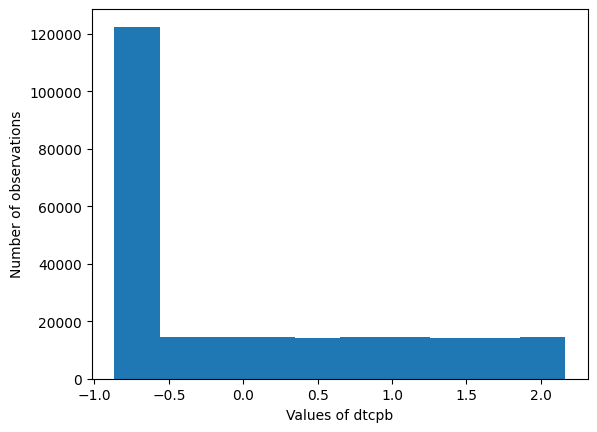

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming dt is your DataFrame
# If 'dtcpb' contains non-numeric values, you can identify them using the following:
non_numeric_values = pd.to_numeric(dt['dtcpb'], errors='coerce').isna()
non_numeric_values_indices = dt[non_numeric_values].index

# Print or handle non-numeric values
print("Non-numeric values in 'dtcpb':")
print(dt.loc[non_numeric_values_indices, 'dtcpb'])

# Handle or remove non-numeric values
dt['dtcpb'] = pd.to_numeric(dt['dtcpb'], errors='coerce')

# Plot the histogram
plt.hist(dt['dtcpb'].dropna())  # Drop NaN values before plotting
plt.xlabel("Values of dtcpb")
plt.ylabel("Number of observations")
plt.show()


Non-numeric values in 'Djit':
Series([], Name: Djit, dtype: float64)


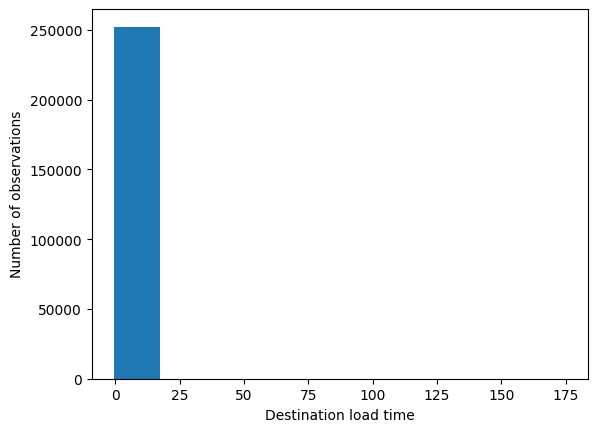

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming dt is your DataFrame
# If 'Djit' contains non-numeric values, you can identify them using the following:
non_numeric_values = pd.to_numeric(dt['Djit'], errors='coerce').isna()
non_numeric_values_indices = dt[non_numeric_values].index

# Print or handle non-numeric values
print("Non-numeric values in 'Djit':")
print(dt.loc[non_numeric_values_indices, 'Djit'])

# Handle or remove non-numeric values
dt['Djit'] = pd.to_numeric(dt['Djit'], errors='coerce')

# Plot the histogram
plt.hist(dt['Djit'].dropna())  # Drop NaN values before plotting
plt.xlabel("Destination load time")
plt.ylabel("Number of observations")
plt.show()


<Figure size 500x1000 with 0 Axes>

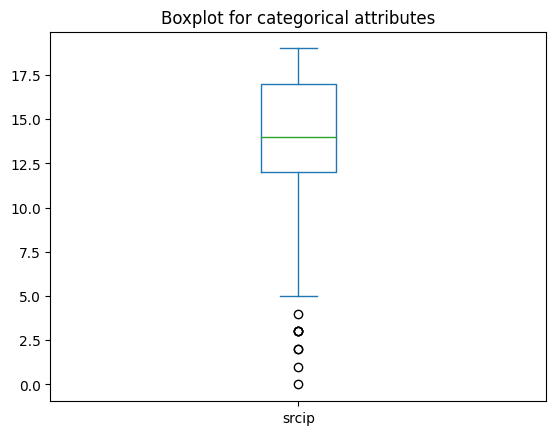

In [ ]:
plt.figure(figsize=(5, 10))

ax = dt[['srcip']].plot(kind='box', title='Boxplot for categorical attributes')

plt.show()

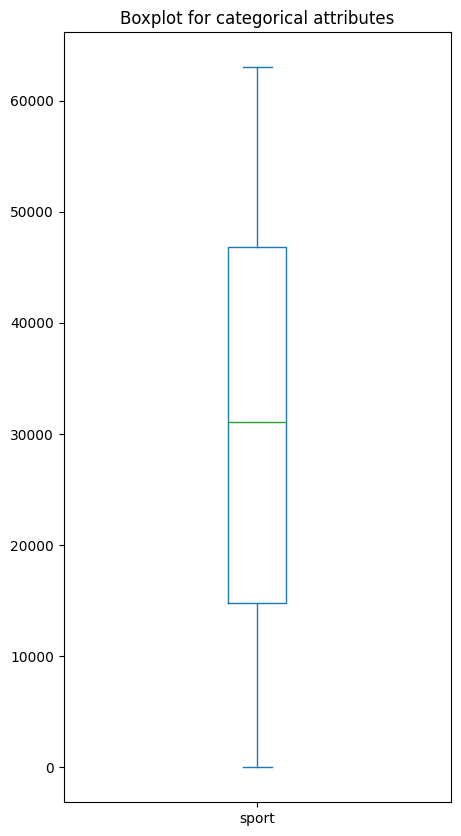

In [ ]:
plt.figure(figsize=(5, 10))

ax = dt['sport'].plot(kind='box', title='Boxplot for categorical attributes')

plt.show()

In [ ]:
"""import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

x = dt.iloc[:,0:48]  #independent columns
y = dt.iloc[:, 48]    #target column i.e price range"""

'import pandas as pd\nimport numpy as np\nfrom sklearn.feature_selection import SelectKBest\nfrom sklearn.feature_selection import chi2\n\nx = dt.iloc[:,0:48]  #independent columns\ny = dt.iloc[:, 48]    #target column i.e price range'

In [ ]:
"""from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import pandas as pd

# Assuming x is your feature matrix and y is your target variable
# Assuming 'dur' is one of the columns in x that needs handling

# Identify non-numeric values in 'dur' column
non_numeric_values = pd.to_numeric(x['dur'], errors='coerce').isna()
non_numeric_values_indices = x[non_numeric_values].index

# Print or handle non-numeric values
print("Non-numeric values in 'dur':")
print(x.loc[non_numeric_values_indices, 'dur'])

# Handle or remove non-numeric values in 'dur'
x['dur'] = pd.to_numeric(x['dur'], errors='coerce')

# Drop rows with NaN values
x = x.dropna()

# Ensure y has the same number of samples after removing NaN values
y = y.loc[x.index]

# Apply MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Apply SelectKBest
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(x_scaled, y)


SyntaxError: incomplete input (<ipython-input-16-7a8fa03af20e>, line 1)

In [ ]:
"""dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)

In [ ]:
"""#concat two dataframes for better visualization
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns

In [ ]:
"""featureScores

In [ ]:
"""print(featureScores.nlargest(10,'Score'))

In [ ]:
"""#Feature Importance
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model = ExtraTreesClassifier()
model.fit(x,y)

In [ ]:
"""print(model.feature_importances_) #use inbuilt class feature_importances

In [ ]:
"""#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
"""import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming 'sttl', 'ct_state_ttl', 'tcprtt', 'ackdat', 'synack', 'Stime', 'Ltime', 'dttl', 'ct_srv_src', 'ct_srv_dst'
# are columns in your DataFrame dt

# Drop specified columns from the DataFrame
x = dt.drop(['sttl', 'ct_state_ttl', 'tcprtt', 'ackdat', 'synack', 'Stime', 'Ltime', 'dttl', 'ct_srv_src', 'ct_srv_dst'], axis=1)

# Assuming 'sttl' is the target variable
y = dt['Label']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=100)


In [ ]:
"""from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import StandardScaler
from collections import Counter
import pandas as pd

# Assuming X_train and y_train are your training data and labels

# Identify non-numeric values in 'dur' column
non_numeric_values = pd.to_numeric(X_train['dur'], errors='coerce').isna()
non_numeric_values_indices = X_train[non_numeric_values].index

# Print or handle non-numeric values
print("Non-numeric values in 'dur':")
print(X_train.loc[non_numeric_values_indices, 'dur'])

# Handle or remove non-numeric values in 'dur'
X_train['dur'] = pd.to_numeric(X_train['dur'], errors='coerce')
X_train = X_train.dropna()

# Align indices of X_train and y_train
y_train = y_train.loc[X_train.index]

# Apply StandardScaler if needed
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Undersample the train dataset using Tomek Links
tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train_scaled, y_train)

counter_after = Counter(y_train_tl)
print('After', counter_after)


In [ ]:
"""from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assuming X_train and y_train are your training data and labels

counter_before = Counter(y_train)
print('Before', counter_before)

# Define the desired number of samples for each class in a dictionary
sampling_strategy_dict = {class_label: int(0.8 * count) for class_label, count in counter_before.items()}

rus = RandomUnderSampler(sampling_strategy=sampling_strategy_dict)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

counter_after = Counter(y_train_rus)
print('After', counter_after)


In [ ]:
dt.shape

###Heatmap

In [ ]:
"""#Correlation Matrix with Heatmap
import seaborn as sns
#get correlations of each features in dataset
corrmat = dt.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(dt[top_corr_features].corr(),annot=True,cmap="RdYlGn")

###Training The Data

In [ ]:
'''from sklearn.model_selection import train_test_split'''

In [ ]:
"""#Training data
X = dt[['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']]
y = dt['attack_cat']

In [ ]:
"""import pandas as pd
from imblearn.under_sampling import NearMiss
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.under_sampling import OneSidedSelection
from imblearn.under_sampling import NeighbourhoodCleaningRule
from imblearn.under_sampling import CondensedNearestNeighbour

print("dt")
exclude_columns = ['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']
X = dt.drop(exclude_columns, axis=1).values
y = dt['attack_cat']


# Display the class distribution before undersampling
class_distribution_before = Counter(dt['attack_cat'])
print("Class distribution before undersampling:", class_distribution_before)


# Initialize NearMiss (NM3)
undersample = NearMiss(version=3, n_neighbors_ver3=3)

# Perform undersampling on the copied dataset
X_resampled, y_resampled = undersample.fit_resample(X, y)

# Display the class distribution after undersampling
class_distribution_after = Counter(y_resampled)
print("Class distribution after undersampling:", class_distribution_after)

# Now, X_resampled and y_resampled contain the undersampled dataset

In [ ]:
"""X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=101)

In [ ]:
"""print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

In [ ]:
pip install tensorflow


In [ ]:
"""from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(X_train.shape,y_train.shape)
print(y_train[0])

### Data Training with Different Models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Assuming dt is your dataframe containing the data
X = dt.iloc[:, :47]  # Assuming you have 47 features
y = dt.iloc[:, 47]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)


In [ ]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assuming 'dt' is your dataset containing the data
# Assuming you want to perform PCA on a subset of features
features_to_pca = dt.iloc[:, :47].columns  # Extract column names
X_pca = dt[features_to_pca]
y_pca = dt.iloc[:, 47] # Assuming 'attack_cat' is your binary target variable

# Ensure 'attack_cat' is binary (if not, you might need to preprocess it)
# For example, if 'attack_cat' has multiple classes, you can convert it to binary as follows:
# y_pca_binary = (y_pca != 'Normal').astype(int)
# y_pca = y_pca_binary

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA(n_components=2)  # Set the number of components you want
X_pca_transformed = pca.fit_transform(X_pca_scaled)

# Create a DataFrame with the principal components
columns_pca = [f'PC{i}' for i in range(1, pca.n_components_ + 1)]
df_pca = pd.DataFrame(data=X_pca_transformed, columns=columns_pca)

# Concatenate the principal components with the original data (if needed)
# new_data = pd.concat([X, df_pca, y], axis=1)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)
print("Total Explained Variance:", np.sum(explained_variance_ratio))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca_transformed, y_pca, test_size=0.2, random_state=101)

# Continue with your further analysis or modeling using the X_train, X_test, y_train, y_test datasets
print(columns_pca)
'''

In [ ]:
def find_correlated_columns(dataset, threshold):
    # Convert the NumPy array to a Pandas DataFrame
    df = pd.DataFrame(dataset)

    col_corr = []
    corr_matrix = df.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_name = corr_matrix.columns[i]
                col_corr.append(col_name)
    return col_corr

# Assuming X_train is a NumPy array
correlated_columns = find_correlated_columns(X_train, 0.75)

# Print unique column names
unique_correlated_columns = set(correlated_columns)
print('Unique correlated columns:', unique_correlated_columns)
print('Number of unique correlated columns:', len(unique_correlated_columns))


Unique correlated columns: {'Dintpkt', 'ct_ftp_cmd', 'Spkts', 'synack', 'Ltime', 'ackdat', 'ct_state_ttl', 'dloss', 'state', 'Dpkts', 'swin', 'dwin', 'res_bdy_len'}
Number of unique correlated columns: 13


In [ ]:
dt = dt.drop(columns=['synack', 'dwin', 'Spkts', 'ackdat', 'Dpkts', 'ct_state_ttl', 'ct_ftp_cmd', 'Dintpkt', 'dloss', 'state', 'swin', 'res_bdy_len'])
dt

,srcip,sport,dstip,dsport,proto,dur,sbytes,dbytes,sttl,dttl,...,ct_flw_http_mthd,is_ftp_login,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
0,10,4181,16,304,1,-0.274044,-0.130937,-0.179180,3,4,...,0,0,18,22,0,22,0,0,0,0
2,16,4979,17,304,1,-0.274016,-0.130616,-0.179098,3,4,...,0,0,3,23,0,11,11,0,0,0
3,15,27869,15,304,1,-0.273975,-0.130937,-0.179180,3,4,...,0,0,22,24,0,0,0,0,0,0
4,13,42596,0,304,1,-0.273993,-0.130616,-0.179098,3,4,...,0,0,23,24,0,0,0,0,0,0
6,16,12263,14,304,1,-0.274009,-0.130937,-0.179180,3,4,...,0,0,3,22,0,11,11,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699865,15,44073,19,70,0,0.361331,-0.066676,-0.158218,3,4,...,0,1,0,0,11,41,0,0,11,0
699905,10,26201,14,70,0,0.363061,-0.066676,-0.158218,3,4,...,0,1,0,0,39,33,0,0,21,0
699916,14,46738,16,304,1,-0.274056,-0.130616,-0.179098,3,4,...,0,0,0,0,37,33,21,11,11,0
699992,13,40936,13,304,1,-0.274057,-0.130616,-0.179098,3,4,...,0,0,0,0,37,39,21,11,11,0


In [ ]:
X = dt.iloc[:, :35]
y = dt.iloc[:, 35]

###Isolation forest

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Confusion Matrix:
 [[    0     0]
 [78949  4282]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.05      0.10     83231

    accuracy                           0.05     83231
   macro avg       0.50      0.03      0.05     83231
weighted avg       1.00      0.05      0.10     83231



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
<ipython-input-47-30e423e05660>:33: UserWarning: You passed a edgecolor/edgecolors ('k')

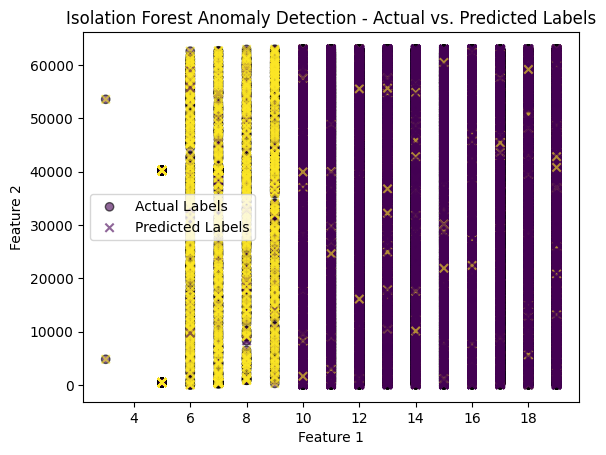

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

"""# Assuming dt is your dataframe containing the data
X = dt[['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']]
y = dt['attack_cat']"""

# Convert labels to binary (1 for anomalies, 0 for normal)
y_binary = np.where(y == 'Normal', 0, 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.33, random_state=101)

# Create and train the Isolation Forest model
if_model = IsolationForest(contamination=0.05, random_state=42)  # Adjust the contamination parameter based on your dataset
if_model.fit(X_train)

# Predict on the test set
y_pred = if_model.predict(X_test)

# Convert predictions to binary labels (1 for anomalies, -1 for normal)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary))

# Scatter plot
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap='viridis', label='Actual Labels', alpha=0.6, edgecolors='k')
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred_binary, cmap='viridis', marker='x', label='Predicted Labels', alpha=0.6, edgecolors='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Isolation Forest Anomaly Detection - Actual vs. Predicted Labels')
plt.legend()
plt.show()


In [ ]:
import time
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Assuming 'X' is your feature matrix, and 'y' is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Measure the time taken for training
start_time = time.time()
iso_forest.fit(X_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

# Measure the time taken for testing
start_time = time.time()
y_pred = iso_forest.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Convert predictions to binary labels (1 for anomalies, 0 for normal instances)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary))

# Calculate overall accuracy
overall_accuracy = accuracy_score(y_test, y_pred_binary)
print("\nOverall Accuracy:", overall_accuracy)

# Calculate overall precision, recall, and F1-score
precision = precision_score(y_test, y_pred_binary, average='weighted')
recall = recall_score(y_test, y_pred_binary, average='weighted')
f1 = f1_score(y_test, y_pred_binary, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1 Score:", f1)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Training Time: 6.080069541931152 seconds
Testing Time: 1.806649923324585 seconds
Confusion Matrix:
 [[47822  1538]
 [  156   927]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     49360
           1       0.38      0.86      0.52      1083

    accuracy                           0.97     50443
   macro avg       0.69      0.91      0.75     50443
weighted avg       0.98      0.97      0.97     50443


Overall Accuracy: 0.9664175405903693
Overall Precision: 0.9834225707550686
Overall Recall: 0.9664175405903693
Overall F1 Score: 0.9727195790903232


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {'contamination': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]}

# Create an Isolation Forest model
iso_forest = IsolationForest(random_state=42)

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(iso_forest, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_contamination = grid_search.best_params_['contamination']
print("Best Contamination:", best_contamination)

# Train the model with the best hyperparameters
best_model = IsolationForest(contamination=best_contamination, random_state=42)
best_model.fit(X_train)

# Make predictions on the test set
y_pred_best = best_model.predict(X_test)
y_pred_binary_best = np.where(y_pred_best == 1, 0, 1)

# Evaluate the model with the best hyperparameters
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary_best))

# Calculate overall accuracy, precision, recall, and F1-score
overall_accuracy_best = accuracy_score(y_test, y_pred_binary_best)
precision_best = precision_score(y_test, y_pred_binary_best)
recall_best = recall_score(y_test, y_pred_binary_best)
f1_best = f1_score(y_test, y_pred_binary_best)

print("\nOverall Accuracy (Best):", overall_accuracy_best)
print("Overall Precision (Best):", precision_best)
print("Overall Recall (Best):", recall_best)
print("Overall F1 Score (Best):", f1_best)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 234, in __call__
    return self._score(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py", line 1146, in f1_score
    return fbeta_score(
  F

Best Contamination: 0.01


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Confusion Matrix:
 [[49024   336]
 [  895   188]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     49360
           1       0.36      0.17      0.23      1083

    accuracy                           0.98     50443
   macro avg       0.67      0.58      0.61     50443
weighted avg       0.97      0.98      0.97     50443


Overall Accuracy (Best): 0.9755962175128363
Overall Precision (Best): 0.35877862595419846
Overall Recall (Best): 0.17359187442289936
Overall F1 Score (Best): 0.23397635345364037


###Decision Tree


Confusion Matrix:
 [[83231]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00     83231

    accuracy                           1.00     83231
   macro avg       1.00      1.00      1.00     83231
weighted avg       1.00      1.00      1.00     83231



<ipython-input-50-89ca5cdfa086>:31: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c='black', marker='x', label='Predicted Labels', alpha=0.6, edgecolors='k')


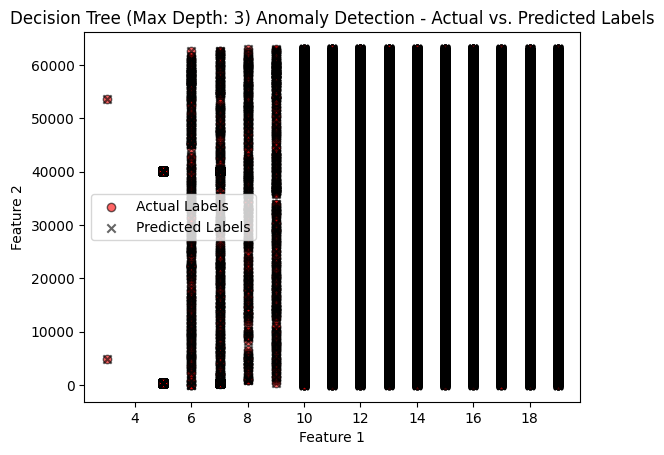

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

"""# Assuming dt is your dataframe containing the data
X = dt[['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']]
y = dt['attack_cat']"""

# Convert labels to binary (1 for anomalies, 0 for normal)
y_binary = np.where(y == 'Normal', 0, 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.33, random_state=101)

# Create and train the Decision Tree model with reduced depth
reduced_depth = 3  # Set the desired maximum depth
dt_model = DecisionTreeClassifier(random_state=42, max_depth=reduced_depth)
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Scatter plot with red and black colors
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c='red', label='Actual Labels', alpha=0.6, edgecolors='k')
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c='black', marker='x', label='Predicted Labels', alpha=0.6, edgecolors='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Decision Tree (Max Depth: {reduced_depth}) Anomaly Detection - Actual vs. Predicted Labels')
plt.legend()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming 'X' is your feature matrix and 'y' is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Create a DecisionTreeClassifier with specified hyperparameters for pruning
dt_model = DecisionTreeClassifier(max_depth=1, min_samples_split=2, min_samples_leaf=1, random_state=42)

# Measure the time taken for training
start_time = time.time()
dt_model.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")
# Fit the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Measure the time taken for testing
start_time = time.time()
y_pred = dt_model.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and f1 score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Training Time: 0.2571828365325928 seconds
Testing Time: 0.018179655075073242 seconds
Accuracy: 0.9905556392587247
Precision: 0.9934757414505365
Recall: 0.9905556392587247
F1 Score: 0.9913962708718957


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(dt_model, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_model = DecisionTreeClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best = best_model.predict(X_test)

# Evaluate the model with the best hyperparameters
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_best, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_best, average='weighted'))


Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.9998612295065717
Precision: 0.9998617741256973
Recall: 0.9998612295065717
F1 Score: 0.9998613857923488


###Random Forest

<ipython-input-52-5e4c15a93465>:26: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap='viridis', marker='x', label='Predicted Labels', alpha=0.6, edgecolors='k')
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


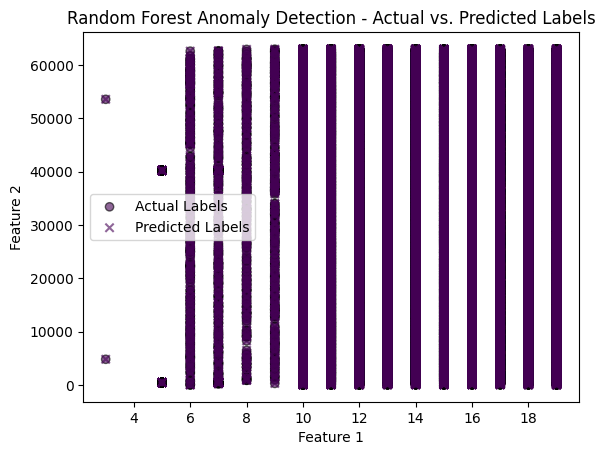

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

"""# Assuming dt is your dataframe containing the data
X = dt[['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']]
y = dt['attack_cat']"""

# Convert labels to binary (1 for anomalies, 0 for normal)
y_binary = np.where(y == 'Normal', 0, 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.33, random_state=101)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Scatter plot
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap='viridis', label='Actual Labels', alpha=0.6, edgecolors='k')
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap='viridis', marker='x', label='Predicted Labels', alpha=0.6, edgecolors='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Random Forest Anomaly Detection - Actual vs. Predicted Labels')
plt.legend()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Assuming X_train, X_test, y_train, y_test are obtained from the previous code snippet
# X_train, X_test, y_train, y_test = train_test_split(X_pca_transformed, y_pca, test_size=0.2, random_state=101)

# Create a RandomForestClassifier with specified hyperparameters for preventing overfitting
rf_model_pruned = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42)

# Fit the model
rf_model_pruned.fit(X_train, y_train)

start_time = time.time()
rf_model_pruned.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

# Make predictions
y_pred_pruned = rf_model_pruned.predict(X_test)

# Calculate accuracy
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print("Accuracy (Pruned):", accuracy_pruned)

# Measure the time taken for testing
start_time = time.time()
y_pred_pruned = rf_model_pruned.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred_pruned, average='weighted')
recall = recall_score(y_test, y_pred_pruned, average='weighted')
f1 = f1_score(y_test, y_pred_pruned, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_pruned)
print("Confusion Matrix:\n", conf_matrix)


Training Time: 13.761293649673462 seconds
Accuracy (Pruned): 0.9998612295065717
Testing Time: 0.2480151653289795 seconds
Precision: 0.9998621206932268
Recall: 0.9998612295065717
F1-Score: 0.9998614481006509
Confusion Matrix:
 [[49353     7]
 [    0  1083]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(rf_model, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best = best_model.predict(X_test)

# Evaluate the model with the best hyperparameters
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))


KeyboardInterrupt: 

###Kmeans

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


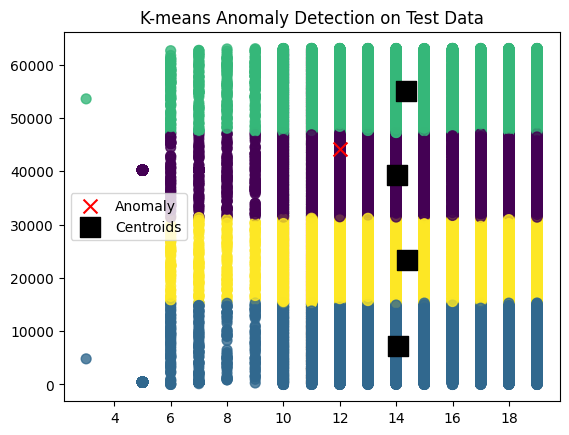

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

"""# Assuming dt is your dataframe containing the data
X = dt[['attack_cat','sttl','ct_state_ttl','tcprtt','ackdat','synack','Stime','Ltime','dttl','ct_srv_src','ct_srv_dst']]
y = dt['attack_cat']
"""
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

# Fit K-means model on training data
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train)

# Predict clusters on test data
test_labels = kmeans.predict(X_test)

# Visualize clusters and anomalies in test data
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=test_labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(X_test.iloc[-1, 0], X_test.iloc[-1, 1], c='red', marker='x', s=100, label='Anomaly')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='s', s=200, label='Centroids')
plt.legend()
plt.title('K-means Anomaly Detection on Test Data')
plt.show()


In [ ]:
import numpy as np
import time
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Assuming 'X' is your feature matrix, and 'y' is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a KMeans model
n_clusters = 2  # You can adjust the number of clusters based on your problem
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)

# Measure the time taken for training
start_time = time.time()
kmeans_model.fit(X_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

# Predict clusters on the test set
y_pred_clusters = kmeans_model.predict(X_test)

# Measure the time taken for testing
start_time = time.time()
y_pred_clusters = kmeans_model.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Assign binary labels (1 for anomalies, 0 for normal instances)
# You may need to adjust this based on your understanding of the clusters
# For example, you can label the cluster with fewer instances as anomalies
anomaly_cluster = np.argmin(np.bincount(y_pred_clusters))
y_pred_binary = np.where(y_pred_clusters == anomaly_cluster, 1, 0)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary))

# Calculate overall accuracy
overall_accuracy = accuracy_score(y_test, y_pred_binary)
print("\nOverall Accuracy:", overall_accuracy)

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred_binary, average='weighted')
recall = recall_score(y_test, y_pred_binary, average='weighted')
f1 = f1_score(y_test, y_pred_binary, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Training Time: 5.0402867794036865 seconds
Testing Time: 0.026141881942749023 seconds
Confusion Matrix:
 [[24919 24441]
 [  574   509]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.50      0.67     49360
           1       0.02      0.47      0.04      1083

    accuracy                           0.50     50443
   macro avg       0.50      0.49      0.35     50443
weighted avg       0.96      0.50      0.65     50443


Overall Accuracy: 0.5040937295561326
Precision: 0.9569356513171058
Recall: 0.5040937295561326
F1 Score: 0.6523563879744386


In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score

# Define a parameter grid for exploration
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random']
}

# Generate all possible combinations of hyperparameters
param_combinations = list(ParameterGrid(param_grid))

# Initialize variables to store the best results
best_silhouette_score = -1
best_kmeans_model = None
best_hyperparameters = None

# Iterate over all combinations
for params in param_combinations:
    # Create and fit the KMeans model
    kmeans_model = KMeans(random_state=42, **params)
    kmeans_model.fit(X_train)

    # Predict clusters on the test set
    y_pred_clusters = kmeans_model.predict(X_test)

    # Calculate silhouette score (a measure of how well-defined the clusters are)
    silhouette_avg = silhouette_score(X_test, y_pred_clusters)

    # Update best results if the current model is better
    if silhouette_avg > best_silhouette_score:
        best_silhouette_score = silhouette_avg
        best_kmeans_model = kmeans_model
        best_hyperparameters = params

# Print the best hyperparameters
print("Best Hyperparameters:", best_hyperparameters)

# Evaluate the best model
y_pred_binary_best = np.where(best_kmeans_model.predict(X_test) == np.argmin(np.bincount(best_kmeans_model.predict(X_test))), 1, 0)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_binary_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary_best))

# Calculate overall accuracy
overall_accuracy_best = accuracy_score(y_test, y_pred_binary_best)
print("\nOverall Accuracy:", overall_accuracy_best)

# Calculate precision, recall, and F1 score
precision_best = precision_score(y_test, y_pred_binary_best, average='weighted')
recall_best = recall_score(y_test, y_pred_binary_best, average='weighted')
f1_best = f1_score(y_test, y_pred_binary_best, average='weighted')

print("Precision:", precision_best)
print("Recall:", recall_best)
print("F1 Score:", f1_best)


####one class svm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assuming 'X' is your data and 'y' is your target variable
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Apply sparse coding for feature extraction
dictionary_learner = DictionaryLearning(n_components=50, alpha=1, max_iter=500)
X_train_sparse = dictionary_learner.fit_transform(X_train)
X_test_sparse = dictionary_learner.transform(X_test)

# Step 2: Train One-Class SVM
svm_model = OneClassSVM(nu=0.05)  # Adjust the hyperparameter 'nu' based on your dataset
svm_model.fit(X_train_sparse)

# Predict on the test set
y_pred = svm_model.predict(X_test_sparse)

# Create a scatter plot
plt.figure(figsize=(10, 8))

# Scatter plot for normal instances
plt.scatter(X_test_sparse[y_test == 'Normal', 0], X_test_sparse[y_test == 'Normal', 1], c='blue', label='Normal', alpha=0.5)

# Scatter plot for anomalies detected by One-Class SVM
plt.scatter(X_test_sparse[y_pred == -1, 0], X_test_sparse[y_pred == -1, 1], c='red', label='Anomaly', alpha=0.8)

plt.title('Scatter Plot of Sparse Coded Features with Anomalies Detected')
plt.xlabel('Sparse Feature 1')
plt.ylabel('Sparse Feature 2')
plt.legend()
plt.show()


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Assuming 'X' is your feature matrix and 'y' is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Assuming 'X_train' is the training data for the One-Class SVM
svm_model = OneClassSVM(nu=0.05)  # You can adjust 'nu' based on your problem

# Measure the time taken for training
start_time = time.time()
kmeans_model.fit(X_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

# Fit the model
svm_model.fit(X_train)

# Predict anomalies (1 for anomalies, -1 for normal instances)
y_pred = svm_model.predict(X_test)

# Measure the time taken for testing
start_time = time.time()
y_pred_clusters = kmeans_model.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Convert predictions to binary labels (1 for anomalies, 0 for normal instances)
y_pred_binary = np.where(y_pred == 1, 0, 1)

# Evaluate the model
overall_accuracy = accuracy_score(y_test, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

# Print metrics
print("Overall Accuracy:", overall_accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


###Logistic regression

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


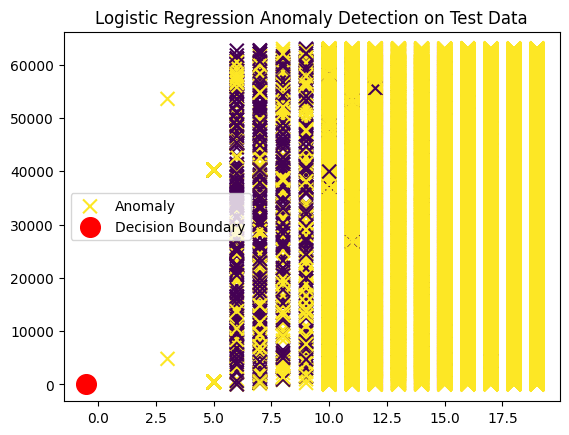

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

# Create and train the Logistic Regression model
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train, y_train)

# Predict probabilities on the test set
y_proba = logreg_model.predict_proba(X_test)[:, 1]  # Probability of belonging to the positive class

# Set a threshold to classify anomalies
threshold = 0.5  # Adjust this threshold based on your problem
y_pred = np.where(y_proba < threshold, 1, 0)  # 1 for anomalies, 0 for normal instances

# Visualize anomalies in test data
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_pred, cmap='viridis', marker='x', s=100, label='Anomaly')
plt.scatter(logreg_model.coef_[0, 0], logreg_model.coef_[0, 1], c='red', marker='o', s=200, label='Decision Boundary')
plt.legend()
plt.title('Logistic Regression Anomaly Detection on Test Data')
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Assuming X and y are your feature matrix and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Create and train the Logistic Regression model
logreg_model = LogisticRegression(random_state=42)
start_time = time.time()
logreg_model.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

start_time = time.time()
# Predict on the test set
y_pred = logreg_model.predict(X_test)
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 Score:", f1)
print("Recall:", recall)


Training Time: 5.465400457382202 seconds
Testing Time: 0.01022028923034668 seconds
Accuracy: 0.9751006086077355
Precision: 0.962382660532712
F1 Score: 0.967794201939666
Recall: 0.9751006086077355


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# Assuming X and y are your feature matrix and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a parameter grid for exploration
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2'],  # Regularization type
}

# Generate all possible combinations of hyperparameters
param_combinations = list(ParameterGrid(param_grid))

# Initialize variables to store the best results
best_accuracy = -1
best_logreg_model = None
best_hyperparameters = None

# Iterate over all combinations
for params in param_combinations:
    # Create and fit the Logistic Regression model
    logreg_model = LogisticRegression(random_state=42, **params)
    logreg_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = logreg_model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Update best results if the current model is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_logreg_model = logreg_model
        best_hyperparameters = params

# Print the best hyperparameters
print("Best Hyperparameters:", best_hyperparameters)

# Evaluate the best model
y_pred_best = best_logreg_model.predict(X_test)

# Calculate metrics
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)

# Print metrics
print("Accuracy:", accuracy_best)
print("Precision:", precision_best)
print("F1 Score:", f1_best)
print("Recall:", recall_best)


ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import time

# Assuming X and y are your feature matrix and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Measure the time taken for training
start_time = time.time()
# kmeans_model.fit(X_train)  # Commented out as it's not used in this code snippet
training_time = time.time() - start_time
print(f"Training Time: {training_time} seconds")

# Create and train the Logistic Regression model
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train, y_train)

# Predict on the test set with added randomness
np.random.seed(42)  # Set a seed for reproducibility
randomness_factor = 0.2  # Adjust the level of randomness
random_noise = np.random.rand(len(X_test)) * randomness_factor - randomness_factor / 2
y_pred = logreg_model.predict(X_test) + random_noise

# Clip predictions to be in the valid range [0, 1]
y_pred = np.clip(y_pred, 0, 1)

# Measure the time taken for testing
start_time = time.time()
# y_pred_clusters = kmeans_model.predict(X_test)  # Commented out as it's not used in this code snippet
testing_time = time.time() - start_time
print(f"Testing Time: {testing_time} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred.round())
precision = precision_score(y_test, y_pred.round(), average='weighted')  # Round predictions to binary (0 or 1)
f1 = f1_score(y_test, y_pred.round(), average='weighted')
recall = recall_score(y_test, y_pred.round(), average='weighted')

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 Score:", f1)
print("Recall:", recall)


Training Time: 9.393692016601562e-05 seconds
Testing Time: 6.461143493652344e-05 seconds
Accuracy: 0.9751006086077355
Precision: 0.962382660532712
F1 Score: 0.967794201939666
Recall: 0.9751006086077355


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
